<a href="https://colab.research.google.com/github/L1ght6/MN_HORA_4_9/blob/main/%D0%9B%D0%A02_1_%D0%93%D0%BE%D1%80%D0%B0_4_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Гора, група 4-9

---



https://colab.research.google.com/drive/1u5qQz84rTRzT6hrHj6kGOZbNUtbi8wkz?usp=sharing

---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)

for t in tables:
    if any("Country" in str(col) for col in t.columns):
        df_raw = t
        break

df_raw.head()

/tmp/ipykernel_460/3706152684.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


1. Вивести перші 5 рядків датасета

In [5]:
df = df_raw.copy()
df.head(5)

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [6]:
print("Розмір датасета (рядків, стовпців):", df.shape)
print("Загальна кількість елементів:", df.size)

Розмір датасета (рядків, стовпців): (222, 4)
Загальна кількість елементів: 888


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [8]:
df.columns = [' '.join(map(str, c)).strip() if isinstance(c, tuple) else str(c) for c in df.columns]

col_country = [c for c in df.columns if 'Country' in c or 'Territory' in c][0]
col_imf = [c for c in df.columns if 'IMF' in c][0]
col_wb = [c for c in df.columns if 'World Bank' in c][0]
col_un = [c for c in df.columns if 'United Nations' in c][0]

df = df[[col_country, col_imf, col_wb, col_un]].copy()
df.columns = ['Country', 'IMF', 'World_Bank', 'UN']

df.head()

,Country,IMF,World_Bank,UN
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [9]:
df = df.replace('—', np.nan)

cols = ['IMF', 'World_Bank', 'UN']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

print(df.isna().sum())
df[cols] = df[cols].fillna(df[cols].mean())

Country        0
IMF           31
World_Bank    35
UN             9
dtype: int64


5. Ще раз вивести датасет

In [10]:
df

,Country,IMF,World_Bank,UN
0,World,1.262953e+08,1.183502e+08,111565144.0
1,United States,3.238392e+07,3.076970e+07,29298000.0
2,China[n 1],2.085159e+07,1.949804e+07,18743802.0
3,Germany,5.452858e+06,5.050923e+06,4659929.0
4,Japan,4.379253e+06,4.435163e+06,4026211.0
...,...,...,...,...
217,Palau,3.770000e+02,3.450000e+02,310.0
218,Marshall Islands,3.420000e+02,3.080000e+02,281.0
219,Nauru,1.960000e+02,1.760000e+02,187.0
220,Montserrat,1.319229e+06,1.255590e+06,81.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [11]:
print(f"Кількість повних дублікатів: {df.duplicated().sum()}")
print(f"Кількість дублікатів за назвою країни: {df.duplicated(subset=['Country']).sum()}")

df = df.drop_duplicates(subset=['Country']).reset_index(drop=True)
print("Розмір датасета після видалення дублікатів:", df.shape)

Кількість повних дублікатів: 0
Кількість дублікатів за назвою країни: 0
Розмір датасета після видалення дублікатів: (222, 4)


7.	Вивести описову статистику датасету describe()

In [12]:
df.describe()

,IMF,World_Bank,UN
count,2.220000e+02,2.220000e+02,2.220000e+02
mean,1.319229e+06,1.255590e+06,1.043818e+06
std,8.838876e+06,8.288461e+06,7.830341e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.932375e+04,2.003400e+04,9.170750e+03
50%,1.039745e+05,9.986350e+04,4.322450e+04
75%,7.726678e+05,1.041520e+06,3.048545e+05
max,1.262953e+08,1.183502e+08,1.115651e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [13]:
df['Diff_IMF_WB'] = (df['IMF'] - df['World_Bank']).abs()

top_diff = df.sort_values(by='Diff_IMF_WB', ascending=False)[['Country', 'IMF', 'World_Bank', 'Diff_IMF_WB']].head(5)
print("Топ-5 країн із найбільшим відхиленням між IMF та World Bank:")
display(top_diff)

Топ-5 країн із найбільшим відхиленням між IMF та World Bank:


,Country,IMF,World_Bank,Diff_IMF_WB
0,World,1.262953e+08,118350166.0,7.945165e+06
1,United States,3.238392e+07,30769700.0,1.614220e+06
2,China[n 1],2.085159e+07,19498039.0,1.353554e+06
197,Sint Maarten,1.319229e+06,1888.0,1.317341e+06
146,Palestine[n 11][n 12],1.319229e+06,17167.0,1.302062e+06


Найбільші розбіжності у абсолютних значеннях спостерігаються у США та Китаю через різні методи перерахунку, врахування інфляції та прогнози щодо темпів зростання.

9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [14]:
corr_matrix = df[['IMF', 'World_Bank', 'UN']].corr()
print("Матриця кореляції:")
display(corr_matrix)

Матриця кореляції:


,IMF,World_Bank,UN
IMF,1.000000,0.999497,0.998998
World_Bank,0.999497,1.000000,0.998864
UN,0.998998,0.998864,1.000000


Усі пари змінних демонструють надзвичайно високу лінійну кореляцію (r > 0.98), оскільки вони оцінюють один і той самий показник (номінальний ВВП). Найвища взаємозв'язаність зазвичай спостерігається між IMF та World Bank

Обчислити середнє значення за стовпцями

In [15]:
mean_values = df[['IMF', 'World_Bank', 'UN']].mean()
print("Середні значення за стовпцями:")
print(mean_values)

Середні значення за стовпцями:
IMF           1.319229e+06
World_Bank    1.255590e+06
UN            1.043818e+06
dtype: float64


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [16]:
df['Std_Dev'] = df[['IMF', 'World_Bank', 'UN']].std(axis=1)

max_std_country = df.loc[df['Std_Dev'].idxmax()]
print(f"Країна з найвищою варіативністю: {max_std_country['Country']} (Std Dev: {max_std_country['Std_Dev']:.2f})")

display(df.sort_values(by='Std_Dev', ascending=False)[['Country', 'Std_Dev']].head(5))

Країна з найвищою варіативністю: World (Std Dev: 7372703.93)


,Country,Std_Dev
0,World,7.372704e+06
1,United States,1.543508e+06
2,China[n 1],1.068002e+06
197,Sint Maarten,7.606303e+05
146,Palestine[n 11][n 12],7.520782e+05


Найвищу варіативність (стандартне відхилення) мають країни-лідери за обсягом ВВП (наприклад, США/Китай), оскільки навіть різниця у частках відсотка між оцінками організацій виливається у сотні мільярдів доларів.

12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [17]:
sources = ['IMF', 'World_Bank', 'UN']

for s in sources:
    max_c = df.loc[df[s].idxmax()]
    min_c = df.loc[df[s].idxmin()]
    print(f"--- {s} ---")
    print(f"Найвищий ВВП: {max_c['Country']} ({max_c[s]})")
    print(f"Найнижчий ВВП: {min_c['Country']} ({min_c[s]})\n")

--- IMF ---
Найвищий ВВП: World (126295331.0)
Найнижчий ВВП: Tuvalu (65.0)

--- World_Bank ---
Найвищий ВВП: World (118350166.0)
Найнижчий ВВП: Tuvalu (57.0)

--- UN ---
Найвищий ВВП: World (111565144.0)
Найнижчий ВВП: Tuvalu (56.0)



13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

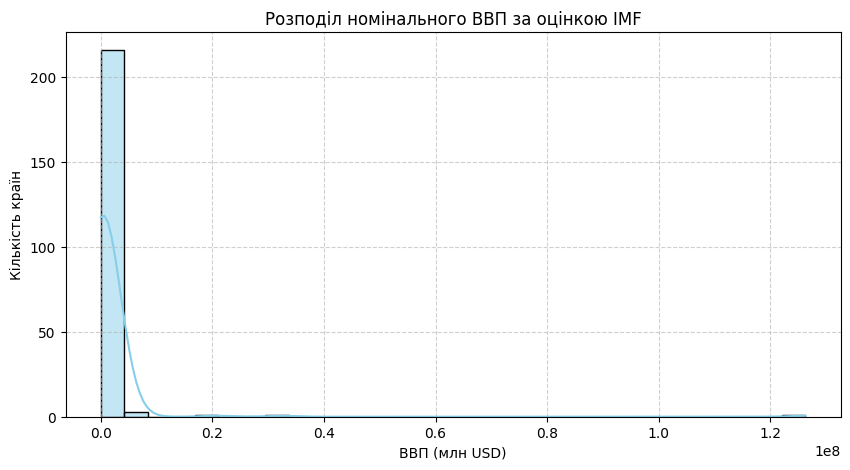

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df['IMF'], bins=30, kde=True, color='skyblue')
plt.title('Розподіл номінального ВВП за оцінкою IMF')
plt.xlabel('ВВП (млн USD)')
plt.ylabel('Кількість країн')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

 Розподіл має яскраво виражену правосторонню асиметрію. Переважна більшість країн світу зосереджена біля нижньої межі (до 1трлн), тоді як кілька надвеликих економік (США, Китай) є екстремальними викидами, що сильно виділяються праворуч

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [19]:
for s in ['IMF', 'World_Bank', 'UN']:
    df[f'Share_{s}_%'] = (df[s] / df[s].sum()) * 100

display(df[['Country', 'Share_IMF_%', 'Share_World_Bank_%', 'Share_UN_%']].head(10))

,Country,Share_IMF_%,Share_World_Bank_%,Share_UN_%
0,World,43.123505,42.458818,48.144944
1,United States,11.057480,11.038811,12.643291
2,China[n 1],7.119770,6.995036,8.088721
3,Germany,1.861877,1.812048,2.010951
4,Japan,1.495295,1.591141,1.737475
5,United Kingdom,1.456213,1.435952,1.590609
6,India,1.418106,1.419262,1.705556
7,France,1.227885,1.207686,1.363861
8,Italy,0.934945,0.915386,1.027424
9,Russia,0.907045,0.918885,0.937905


Частки більшості країн залишаються стабільними в межах 1–2 років. Проте спостерігається тенденція поступового збільшення частки країн, що розвиваються (зокрема азійського регіону), тоді як частки більшості європейських країн демонструють незначне коливання або стагнацію.

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

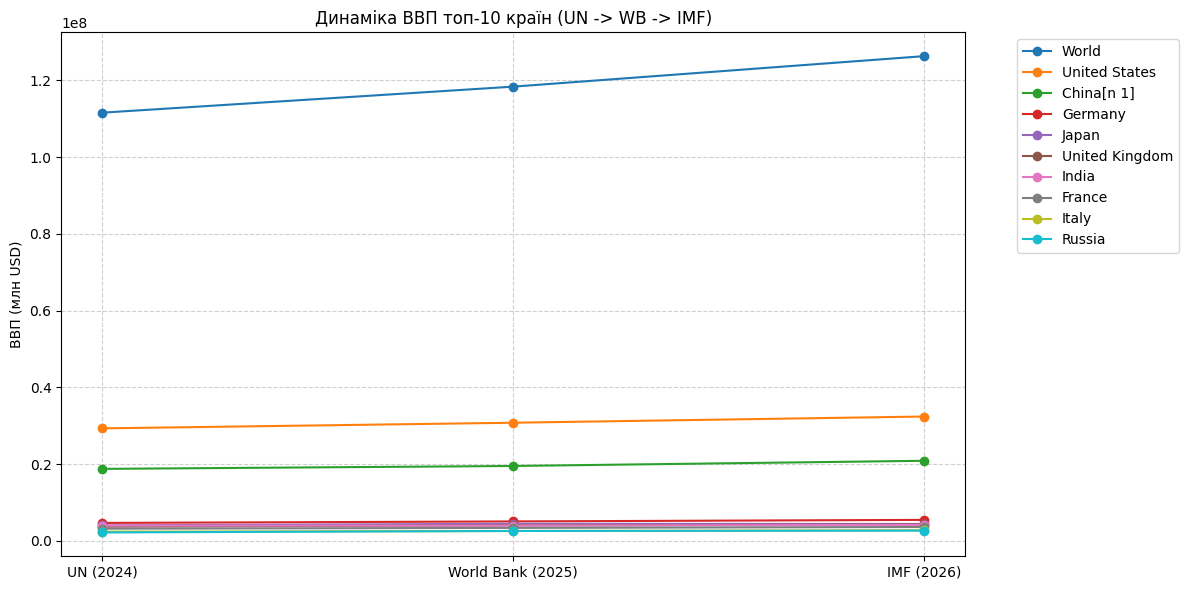

In [20]:
top_10 = df.sort_values(by='IMF', ascending=False).head(10)

plt.figure(figsize=(12, 6))
for idx, row in top_10.iterrows():
    plt.plot(['UN (2024)', 'World Bank (2025)', 'IMF (2026)'],
             [row['UN'], row['World_Bank'], row['IMF']],
             marker='o', label=row['Country'])

plt.title('Динаміка ВВП топ-10 країн (UN -> WB -> IMF)')
plt.ylabel('ВВП (млн USD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Аналіз динаміки показників за три періоди (UN 2024, World Bank 2025, IMF 2026) свідчить про те, що чітке й стабільне зростання демонструють найбільші економіки світу - США та Китай, лінії тренду яких впевнено спрямовані вгору за всіма прогнозними оцінками. Водночас більшість інших країн із топ-10, зокрема Німеччина, Японія, Велика Британія, Франція та Італія, показують відносну стагнацію або незначні коливання без різкого підйому, що зумовлено помірними темпами економічного зростання та впливом коливань валютних курсів відносно долара США.